**"Beyond Color: Analyzing the Robustness of Contrastive Learning under Structural Augmentations"**

1. The Abstract
Self-Supervised Learning (SSL) methods like **SimCLR** allow models to learn visual features without human labels by maximizing the similarity between two augmented views of the same image. The original SimCLR paper argues that **color distortion** is the most critical augmentation to prevent the model from "cheating" by just matching color histograms. In this project, we reproduce the SimCLR baseline on the CIFAR-10 dataset to verify this claim. Then, we introduce a novel variation: we replace the standard color jittering with **Sobel Edge** Filtering (a structural augmentation) to test if removing color information entirely forces the model to learn better shape-based features, potentially improving robustness against color-based adversarial attacks or domain shifts.

2. **The Goal**
To determine if "structural-only" augmentations (like edge detection) can replace "color-based" augmentations (like jitter/blur) in Contrastive Learning, and how this affects the model's ability to classify images.

3. **The "Twist"**
Standard SimCLR relies heavily on Color Jittering (randomly changing brightness/contrast).

   - **The Problem:** The authors claim if you don't distort color, the AI effectively "cheats" and just memorizes the color distribution (e.g., "mostly green" = frog) rather than the shape.

   -  **The Twist:** I will force the model to learn only from shape. I will implement a custom augmentation pipeline that converts images to Sobel Edge Maps (which look like pencil sketches) before feeding them into the network. I'm testing the hypothesis: "Does an Edge-Only SimCLR model learn more robust features than a Color-Jittered model?"

100%|██████████| 170M/170M [00:13<00:00, 13.0MB/s]


Data loaded successfully.


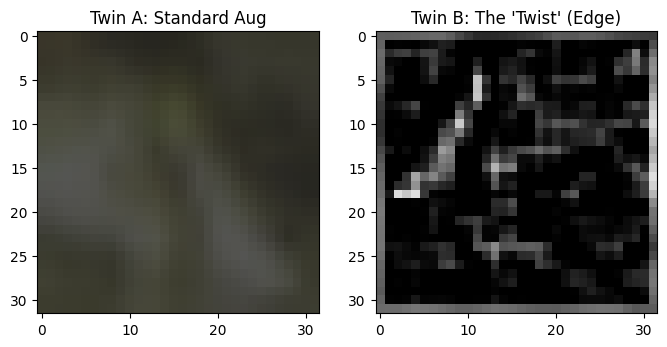

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter

class SobelEdgeTransform:
    def __call__(self, x):
        return x.filter(ImageFilter.FIND_EDGES)

def show_sample(dataset):
    # dataset[0] returns a tuple: ((x1, x2), label)
    (x1, x2), label = dataset[0]

    # Convert tensors back to images for viewing
    to_pil = transforms.ToPILImage()

    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(to_pil(x1))
    ax[0].set_title("Twin A: Standard Aug")
    ax[1].imshow(to_pil(x2), cmap='gray')
    ax[1].set_title("Twin B: The 'Twist' (Edge)")
    plt.show()

# --- 3. Define the Twin Pipeline ---
class SimCLR_Twin_Transform:
    def __init__(self, size=32):
        self.transform_a = transforms.Compose([
            transforms.RandomResizedCrop(size=size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply([
                transforms.ColorJitter(0.8, 0.8, 0.8, 0.2)
            ], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.ToTensor(),
        ])

        self.transform_b = transforms.Compose([
            transforms.RandomResizedCrop(size=size),
            transforms.RandomHorizontalFlip(),
            SobelEdgeTransform(),  # The Twist
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
        ])

    def __call__(self, x):
        x_i = self.transform_a(x)
        x_j = self.transform_b(x)
        return x_i, x_j

# --- 4. Load Data ---
train_dataset = CIFAR10(
    root='./data',
    train=True,
    transform=SimCLR_Twin_Transform(size=32),
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    drop_last=True,
    num_workers=2
)

# Verify
print("Data loaded successfully.")
show_sample(train_dataset)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# 4. Define the Contrastive Loss (NT-Xent)
# ==========================================
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super(NTXentLoss, self).__init__()
        self.temperature = temperature
        self.criterion = nn.CrossEntropyLoss(reduction="sum")

    def forward(self, z_i, z_j):
        batch_size = z_i.shape[0]

        # 1. Concatenate the two batches of features
        # If batch_size is 128, features will be [256, 128]
        features = torch.cat((z_i, z_j), dim=0)

        # 2. Calculate Cosine Similarity Matrix
        # We normalize the vectors first so dot product = cosine similarity
        features = F.normalize(features, dim=1)
        similarity_matrix = torch.matmul(features, features.T)

        # 3. Create the "Labels" for Cross Entropy
        # For the i-th image, the "correct class" is the (i + batch_size)-th image
        labels = torch.cat([
            torch.arange(batch_size) + batch_size,
            torch.arange(batch_size)
        ], dim=0)
        labels = labels.to(features.device)

        # 4. Mask out self-similarity (similarity of an image with itself is 1.0, we ignore this)
        mask = torch.eye(labels.shape[0], dtype=torch.bool).to(features.device)
        # We set self-similarity to a very small number so it doesn't affect Softmax
        similarity_matrix.masked_fill_(mask, -9e15)

        # 5. Compute Loss
        # The "logits" are the similarity scores divided by temperature
        logits = similarity_matrix / self.temperature
        loss = self.criterion(logits, labels)

        return loss / (2 * batch_size)

# ==========================================
# 5. Define the Training Loop
# ==========================================
def train_simclr(model, train_loader, epochs=5, temperature=0.5):
    # Move model to GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Optimizer (Adam is standard for SimCLR)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

    # Scheduler (helps convergence)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=len(train_loader), eta_min=0, last_epoch=-1
    )

    # Loss Function (NOW USES THE VARIABLE TEMPERATURE)
    criterion = NTXentLoss(temperature=temperature).to(device)

    print(f"Starting training on {device}...")

    loss_history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for i, ((x_i, x_j), _) in enumerate(train_loader):
            # Move images to GPU
            x_i = x_i.to(device)
            x_j = x_j.to(device)

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            _, z_i = model(x_i)
            _, z_j = model(x_j)

            # Calculate Loss
            loss = criterion(z_i, z_j)

            # Backward pass
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Step the scheduler
        scheduler.step()

        # Print stats
        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f}")

    return model, loss_history

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18
import matplotlib.pyplot as plt

# ==========================================
# MASTER LOSS FUNCTION (Accepts Variable Temperature)
# ==========================================
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super(NTXentLoss, self).__init__()
        self.temperature = temperature
        self.criterion = nn.CrossEntropyLoss(reduction="sum")

    def forward(self, z_i, z_j):
        batch_size = z_i.shape[0]
        features = torch.cat((z_i, z_j), dim=0)
        features = F.normalize(features, dim=1)
        similarity_matrix = torch.matmul(features, features.T)

        labels = torch.cat([
            torch.arange(batch_size) + batch_size,
            torch.arange(batch_size)
        ], dim=0).to(features.device)

        mask = torch.eye(labels.shape[0], dtype=torch.bool).to(features.device)
        similarity_matrix.masked_fill_(mask, -9e15)

        logits = similarity_matrix / self.temperature
        loss = self.criterion(logits, labels)

        return loss / (2 * batch_size)

# ==========================================
# MASTER TRAINING LOOP (Accepts Variable Temperature)
# ==========================================
def train_simclr(model, train_loader, epochs=5, temperature=0.5):
    # Move model to GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Optimizer (Adam is standard for SimCLR)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

    # Scheduler (helps convergence)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=len(train_loader), eta_min=0, last_epoch=-1
    )

    # Loss Function (Uses the variable temperature passed into the function!)
    criterion = NTXentLoss(temperature=temperature).to(device)

    print(f"Starting training on {device} (Temperature: {temperature})...")

    loss_history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for i, ((x_i, x_j), _) in enumerate(train_loader):
            # Move images to GPU
            x_i = x_i.to(device)
            x_j = x_j.to(device)

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            _, z_i = model(x_i)
            _, z_j = model(x_j)

            # Calculate Loss
            loss = criterion(z_i, z_j)

            # Backward pass
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Step the scheduler
        scheduler.step()

        # Print stats
        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f}")

    return model, loss_history

print("Master Loss Function and Training Loop successfully loaded!")

Master Loss Function and Training Loop successfully loaded!


Starting training on cuda (Temperature: 0.5)...
Epoch [1/3] | Loss: 5.1518
Epoch [2/3] | Loss: 4.8468
Epoch [3/3] | Loss: 4.6996


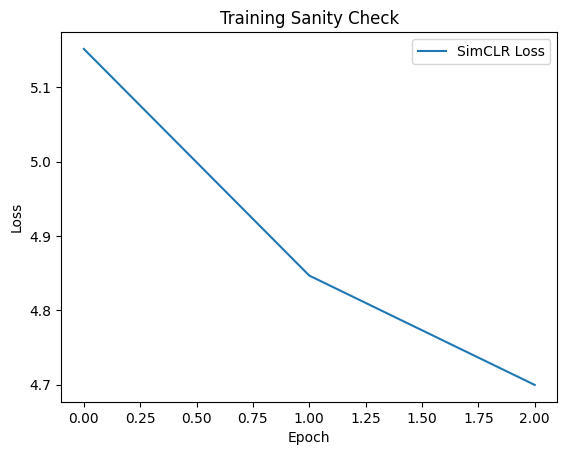

In [ ]:
# ==========================================
# 6. Run the Training (Sanity Check)
# ==========================================

# 1. Initialize the Model
# We need to move it to GPU (cuda) immediately
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimCLR_ResNet().to(device)

# 2. Call the function we defined earlier
# This is what triggers the print statement and the loop
trained_model, history = train_simclr(model, train_loader, epochs=3)

# 3. Plot the results
plt.plot(history, label='SimCLR Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Sanity Check')
plt.legend()
plt.show()

In [ ]:
# ==========================================
# 7. Linear Probing (Evaluation) Setup
# ==========================================

# 1. Load Standard CIFAR-10 (No twins, just normal images + labels)
transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Standard normalization
])

train_eval_dataset = CIFAR10(root='./data', train=True, transform=transform_eval, download=True)
train_eval_loader = DataLoader(train_eval_dataset, batch_size=128, shuffle=True)

test_dataset = CIFAR10(root='./data', train=False, transform=transform_eval, download=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# 2. Build the Linear Evaluator
class LinearEvaluation(nn.Module):
    def __init__(self, base_encoder, num_classes=10):
        super(LinearEvaluation, self).__init__()
        self.encoder = base_encoder

        # FREEZE THE ENCODER!
        # We don't want to ruin the self-supervised features we just learned.
        for param in self.encoder.parameters():
            param.requires_grad = False

        # Add a single Linear layer for the 10 CIFAR classes
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        # Pass image through frozen encoder
        with torch.no_grad():
            features = self.encoder(x)
        # Pass features to classifier
        return self.classifier(features)

# 3. Initialize the model and move to GPU
eval_model = LinearEvaluation(model.encoder).to(device)

print("Standard Data Loaded. Linear Evaluation Model is built and frozen!")

Standard Data Loaded. Linear Evaluation Model is built and frozen!


In [ ]:
# ==========================================
# 8. Train the Classifier & Test Accuracy
# ==========================================

def train_and_test_linear(eval_model, train_loader, test_loader, epochs=25):
    # Only optimize the classifier weights! The encoder is frozen.
    optimizer = torch.optim.Adam(eval_model.classifier.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    print("Training the linear classifier...")

    for epoch in range(epochs):
        eval_model.train()
        total_loss = 0 # calculate average loss

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = eval_model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() # keep track of loss


        avg_loss = total_loss / len(train_loader)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | LR: {current_lr:.6f}")

    # Now, let's test the accuracy on unseen data!
    eval_model.eval()
    correct = 0
    total = 0

    print("Testing accuracy on unseen data...")
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = eval_model(images)

            # Get the predicted class (the one with the highest probability)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"=====================================")
    print(f"Final Model Accuracy: {accuracy:.2f}%")
    print(f"=====================================")

    return accuracy

# Run the test!
final_accuracy = train_and_test_linear(eval_model, train_eval_loader, test_loader, epochs=25)

Training the linear classifier...
Epoch [1/25] | Loss: 1.7220 | LR: 0.001000
Epoch [2/25] | Loss: 1.6411 | LR: 0.001000
Epoch [3/25] | Loss: 1.6102 | LR: 0.001000
Epoch [4/25] | Loss: 1.5917 | LR: 0.001000
Epoch [5/25] | Loss: 1.5721 | LR: 0.001000
Epoch [6/25] | Loss: 1.5592 | LR: 0.001000
Epoch [7/25] | Loss: 1.5493 | LR: 0.001000
Epoch [8/25] | Loss: 1.5410 | LR: 0.001000
Epoch [9/25] | Loss: 1.5302 | LR: 0.001000
Epoch [10/25] | Loss: 1.5242 | LR: 0.001000
Epoch [11/25] | Loss: 1.5169 | LR: 0.001000
Epoch [12/25] | Loss: 1.5065 | LR: 0.001000
Epoch [13/25] | Loss: 1.5012 | LR: 0.001000
Epoch [14/25] | Loss: 1.4954 | LR: 0.001000
Epoch [15/25] | Loss: 1.4909 | LR: 0.001000
Epoch [16/25] | Loss: 1.4866 | LR: 0.001000
Epoch [17/25] | Loss: 1.4825 | LR: 0.001000
Epoch [18/25] | Loss: 1.4784 | LR: 0.001000
Epoch [19/25] | Loss: 1.4704 | LR: 0.001000
Epoch [20/25] | Loss: 1.4697 | LR: 0.001000
Epoch [21/25] | Loss: 1.4654 | LR: 0.001000
Epoch [22/25] | Loss: 1.4602 | LR: 0.001000
Epoch [

In [ ]:
# ==========================================
# EXPERIMENT 1: The Color Baseline (Track 1)
# ==========================================

# 1. Define the Pure Color Transform (Both twins get color jitter)
class Color_Twin_Transform:
    def __init__(self, size=32):
        self.color_aug = transforms.Compose([
            transforms.RandomResizedCrop(size=size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply([transforms.ColorJitter(0.8, 0.8, 0.8, 0.2)], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.ToTensor(),
        ])
    def __call__(self, x):
        return self.color_aug(x), self.color_aug(x)

# 2. Load the Data
color_dataset = CIFAR10(root='./data', train=True, transform=Color_Twin_Transform(size=32), download=True)
color_loader = DataLoader(color_dataset, batch_size=128, shuffle=True, drop_last=True, num_workers=2)

# 3. Initialize a FRESH Model
color_model = SimCLR_ResNet().to(device)

# 4. Train the "Brain" (Let's do 50 epochs for the real run)
print(">>> Phase 1: Training the COLOR Brain (50 Epochs) <<<")
trained_color_model, color_history = train_simclr(color_model, color_loader, epochs=50)

# 5. Evaluate the "Brain"
print("\n>>> Phase 2: Testing the COLOR Brain (25 Epochs) <<<")
color_eval_model = LinearEvaluation(trained_color_model.encoder).to(device)
color_accuracy = train_and_test_linear(color_eval_model, train_eval_loader, test_loader, epochs=25)

print(f"\nOFFICIAL BASELINE ACCURACY: {color_accuracy:.2f}%")

>>> Phase 1: Training the COLOR Brain (50 Epochs) <<<
Starting training on cuda...
Epoch [1/50] | Loss: 5.2517
Epoch [2/50] | Loss: 4.9187
Epoch [3/50] | Loss: 4.7258
Epoch [4/50] | Loss: 4.5995
Epoch [5/50] | Loss: 4.5238
Epoch [6/50] | Loss: 4.4617
Epoch [7/50] | Loss: 4.4356
Epoch [8/50] | Loss: 4.4036
Epoch [9/50] | Loss: 4.3802
Epoch [10/50] | Loss: 4.3613
Epoch [11/50] | Loss: 4.3438
Epoch [12/50] | Loss: 4.3276
Epoch [13/50] | Loss: 4.3076
Epoch [14/50] | Loss: 4.3027
Epoch [15/50] | Loss: 4.2917
Epoch [16/50] | Loss: 4.2801
Epoch [17/50] | Loss: 4.2786
Epoch [18/50] | Loss: 4.2725
Epoch [19/50] | Loss: 4.2629
Epoch [20/50] | Loss: 4.2547
Epoch [21/50] | Loss: 4.2520
Epoch [22/50] | Loss: 4.2441
Epoch [23/50] | Loss: 4.2410
Epoch [24/50] | Loss: 4.2306
Epoch [25/50] | Loss: 4.2263
Epoch [26/50] | Loss: 4.2211
Epoch [27/50] | Loss: 4.2164
Epoch [28/50] | Loss: 4.2107
Epoch [29/50] | Loss: 4.2079
Epoch [30/50] | Loss: 4.2036
Epoch [31/50] | Loss: 4.2008
Epoch [32/50] | Loss: 4.197

In [ ]:
# ==========================================
# EXPERIMENT 2: The Edge Twist
# ==========================================

# 1. Define the Pure Edge Transform (Both twins get the pencil sketch look)
class Edge_Twin_Transform:
    def __init__(self, size=32):
        self.edge_aug = transforms.Compose([
            transforms.RandomResizedCrop(size=size),
            transforms.RandomHorizontalFlip(),
            SobelEdgeTransform(), # Force structural learning!
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
        ])
    def __call__(self, x):
        return self.edge_aug(x), self.edge_aug(x)

# 2. Load the Data
edge_dataset = CIFAR10(root='./data', train=True, transform=Edge_Twin_Transform(size=32), download=True)
edge_loader = DataLoader(edge_dataset, batch_size=128, shuffle=True, drop_last=True, num_workers=2)

# 3. Initialize another FRESH Model
edge_model = SimCLR_ResNet().to(device)

# 4. Train the "Brain"
print(">>> Phase 1: Training the EDGE Brain (50 Epochs) <<<")
trained_edge_model, edge_history = train_simclr(edge_model, edge_loader, epochs=50)

# 5. Evaluate the "Brain"
print("\n>>> Phase 2: Testing the EDGE Brain (25 Epochs) <<<")
edge_eval_model = LinearEvaluation(trained_edge_model.encoder).to(device)
edge_accuracy = train_and_test_linear(edge_eval_model, train_eval_loader, test_loader, epochs=25)

print(f"\nOFFICIAL TWIST ACCURACY: {edge_accuracy:.2f}%")

>>> Phase 1: Training the EDGE Brain (50 Epochs) <<<
Starting training on cuda...
Epoch [1/50] | Loss: 4.6528
Epoch [2/50] | Loss: 4.4290
Epoch [3/50] | Loss: 4.3499
Epoch [4/50] | Loss: 4.3044
Epoch [5/50] | Loss: 4.2706
Epoch [6/50] | Loss: 4.2388
Epoch [7/50] | Loss: 4.2226
Epoch [8/50] | Loss: 4.2072
Epoch [9/50] | Loss: 4.1984
Epoch [10/50] | Loss: 4.1878
Epoch [11/50] | Loss: 4.1754
Epoch [12/50] | Loss: 4.1689
Epoch [13/50] | Loss: 4.1596
Epoch [14/50] | Loss: 4.1532
Epoch [15/50] | Loss: 4.1428
Epoch [16/50] | Loss: 4.1412
Epoch [17/50] | Loss: 4.1331
Epoch [18/50] | Loss: 4.1284
Epoch [19/50] | Loss: 4.1229
Epoch [20/50] | Loss: 4.1226
Epoch [21/50] | Loss: 4.1172
Epoch [22/50] | Loss: 4.1125
Epoch [23/50] | Loss: 4.1083
Epoch [24/50] | Loss: 4.1063
Epoch [25/50] | Loss: 4.0988
Epoch [26/50] | Loss: 4.0967
Epoch [27/50] | Loss: 4.0919
Epoch [28/50] | Loss: 4.0913
Epoch [29/50] | Loss: 4.0892
Epoch [30/50] | Loss: 4.0881
Epoch [31/50] | Loss: 4.0833
Epoch [32/50] | Loss: 4.0808

In [ ]:
# ==========================================
# EXPERIMENT 3: The Optimized Edge Twist (Checkpoint 2)
# ==========================================

# 1. Define the Optimized Transform
class Optimized_Edge_Twin_Transform:
    def __init__(self, size=32):
        self.edge_aug = transforms.Compose([
            transforms.RandomResizedCrop(size=size, scale=(0.5, 1.0)),
            transforms.RandomHorizontalFlip(),
            SobelEdgeTransform(),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
        ])
    def __call__(self, x):
        return self.edge_aug(x), self.edge_aug(x)

# 2. Load the Optimized Data
opt_edge_dataset = CIFAR10(root='./data', train=True, transform=Optimized_Edge_Twin_Transform(size=32), download=True)
opt_edge_loader = DataLoader(opt_edge_dataset, batch_size=128, shuffle=True, drop_last=True, num_workers=2)

# 3. Initialize a FRESH Model
opt_edge_model = SimCLR_ResNet().to(device)

# 4. Train the "Brain"
print(">>> Phase 1: Training the OPTIMIZED EDGE Brain (150 Epochs) <<<")

# Look here! We are passing temperature=0.1 into our newly updated function
trained_opt_edge_model, opt_edge_history = train_simclr(
    opt_edge_model,
    opt_edge_loader,
    epochs=150,
    temperature=0.1
)

# 5. Evaluate the "Brain"
print("\n>>> Phase 2: Testing the OPTIMIZED EDGE Brain (25 Epochs) <<<")
opt_edge_eval_model = LinearEvaluation(trained_opt_edge_model.encoder).to(device)
opt_edge_accuracy = train_and_test_linear(opt_edge_eval_model, train_eval_loader, test_loader, epochs=25)

print(f"\nOPTIMIZED TWIST ACCURACY: {opt_edge_accuracy:.2f}%")

>>> Phase 1: Training the OPTIMIZED EDGE Brain (150 Epochs) <<<
Starting training on cuda (Temperature: 0.1)...
Epoch [1/150] | Loss: 1.8268
Epoch [2/150] | Loss: 0.6668
Epoch [3/150] | Loss: 0.4646
Epoch [4/150] | Loss: 0.3768
Epoch [5/150] | Loss: 0.3193
Epoch [6/150] | Loss: 0.2804
Epoch [7/150] | Loss: 0.2555
Epoch [8/150] | Loss: 0.2366
Epoch [9/150] | Loss: 0.2242
Epoch [10/150] | Loss: 0.2131
Epoch [11/150] | Loss: 0.2020
Epoch [12/150] | Loss: 0.1958
Epoch [13/150] | Loss: 0.1865
Epoch [14/150] | Loss: 0.1791
Epoch [15/150] | Loss: 0.1746
Epoch [16/150] | Loss: 0.1737
Epoch [17/150] | Loss: 0.1642
Epoch [18/150] | Loss: 0.1610
Epoch [19/150] | Loss: 0.1596
Epoch [20/150] | Loss: 0.1528
Epoch [21/150] | Loss: 0.1555
Epoch [22/150] | Loss: 0.1467
Epoch [23/150] | Loss: 0.1480
Epoch [24/150] | Loss: 0.1440
Epoch [25/150] | Loss: 0.1409
Epoch [26/150] | Loss: 0.1358
Epoch [27/150] | Loss: 0.1366
Epoch [28/150] | Loss: 0.1322
Epoch [29/150] | Loss: 0.1276
Epoch [30/150] | Loss: 0.12